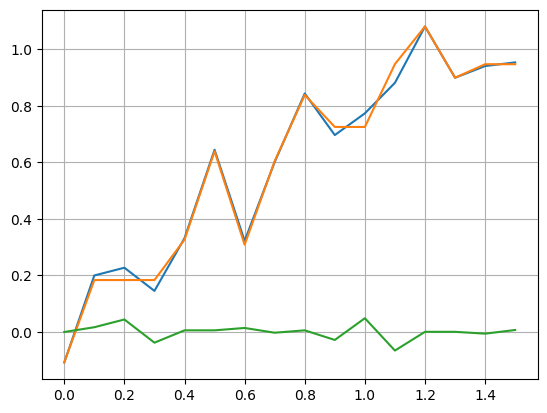

In [1]:
# Алгоритм регрессии AdaBoost на решающих деревьях

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

np.random.seed(123)

x = np.arange(0, np.pi/2, 0.1).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, x.shape)

# plt.plot(x, y)
# plt.grid()
# plt.show()

T = 5                   # число алгоритмов в композиции
max_depth = 2           # максимальная глубина решающих деревьев
algs = []               # список из полученных алгоритмов
s = np.array(y.ravel())
for n in range(T):
    # создаем и обучаем решающее дерево
    algs.append(DecisionTreeRegressor(max_depth=max_depth))
    algs[-1].fit(x, s)

    s -= algs[-1].predict(x)    # пересчитываем остатки


# восстанавливаем исходный сигнал по набору полученных деревьев
yy = algs[0].predict(x)
for n in range(1, T):
    yy += algs[n].predict(x)

# отображаем результаты в виде графиков
plt.plot(x, y)      # исходный график
plt.plot(x, yy)     # восстановленный график
plt.plot(x, s)      # остаточный сигнал
plt.grid()
plt.show()

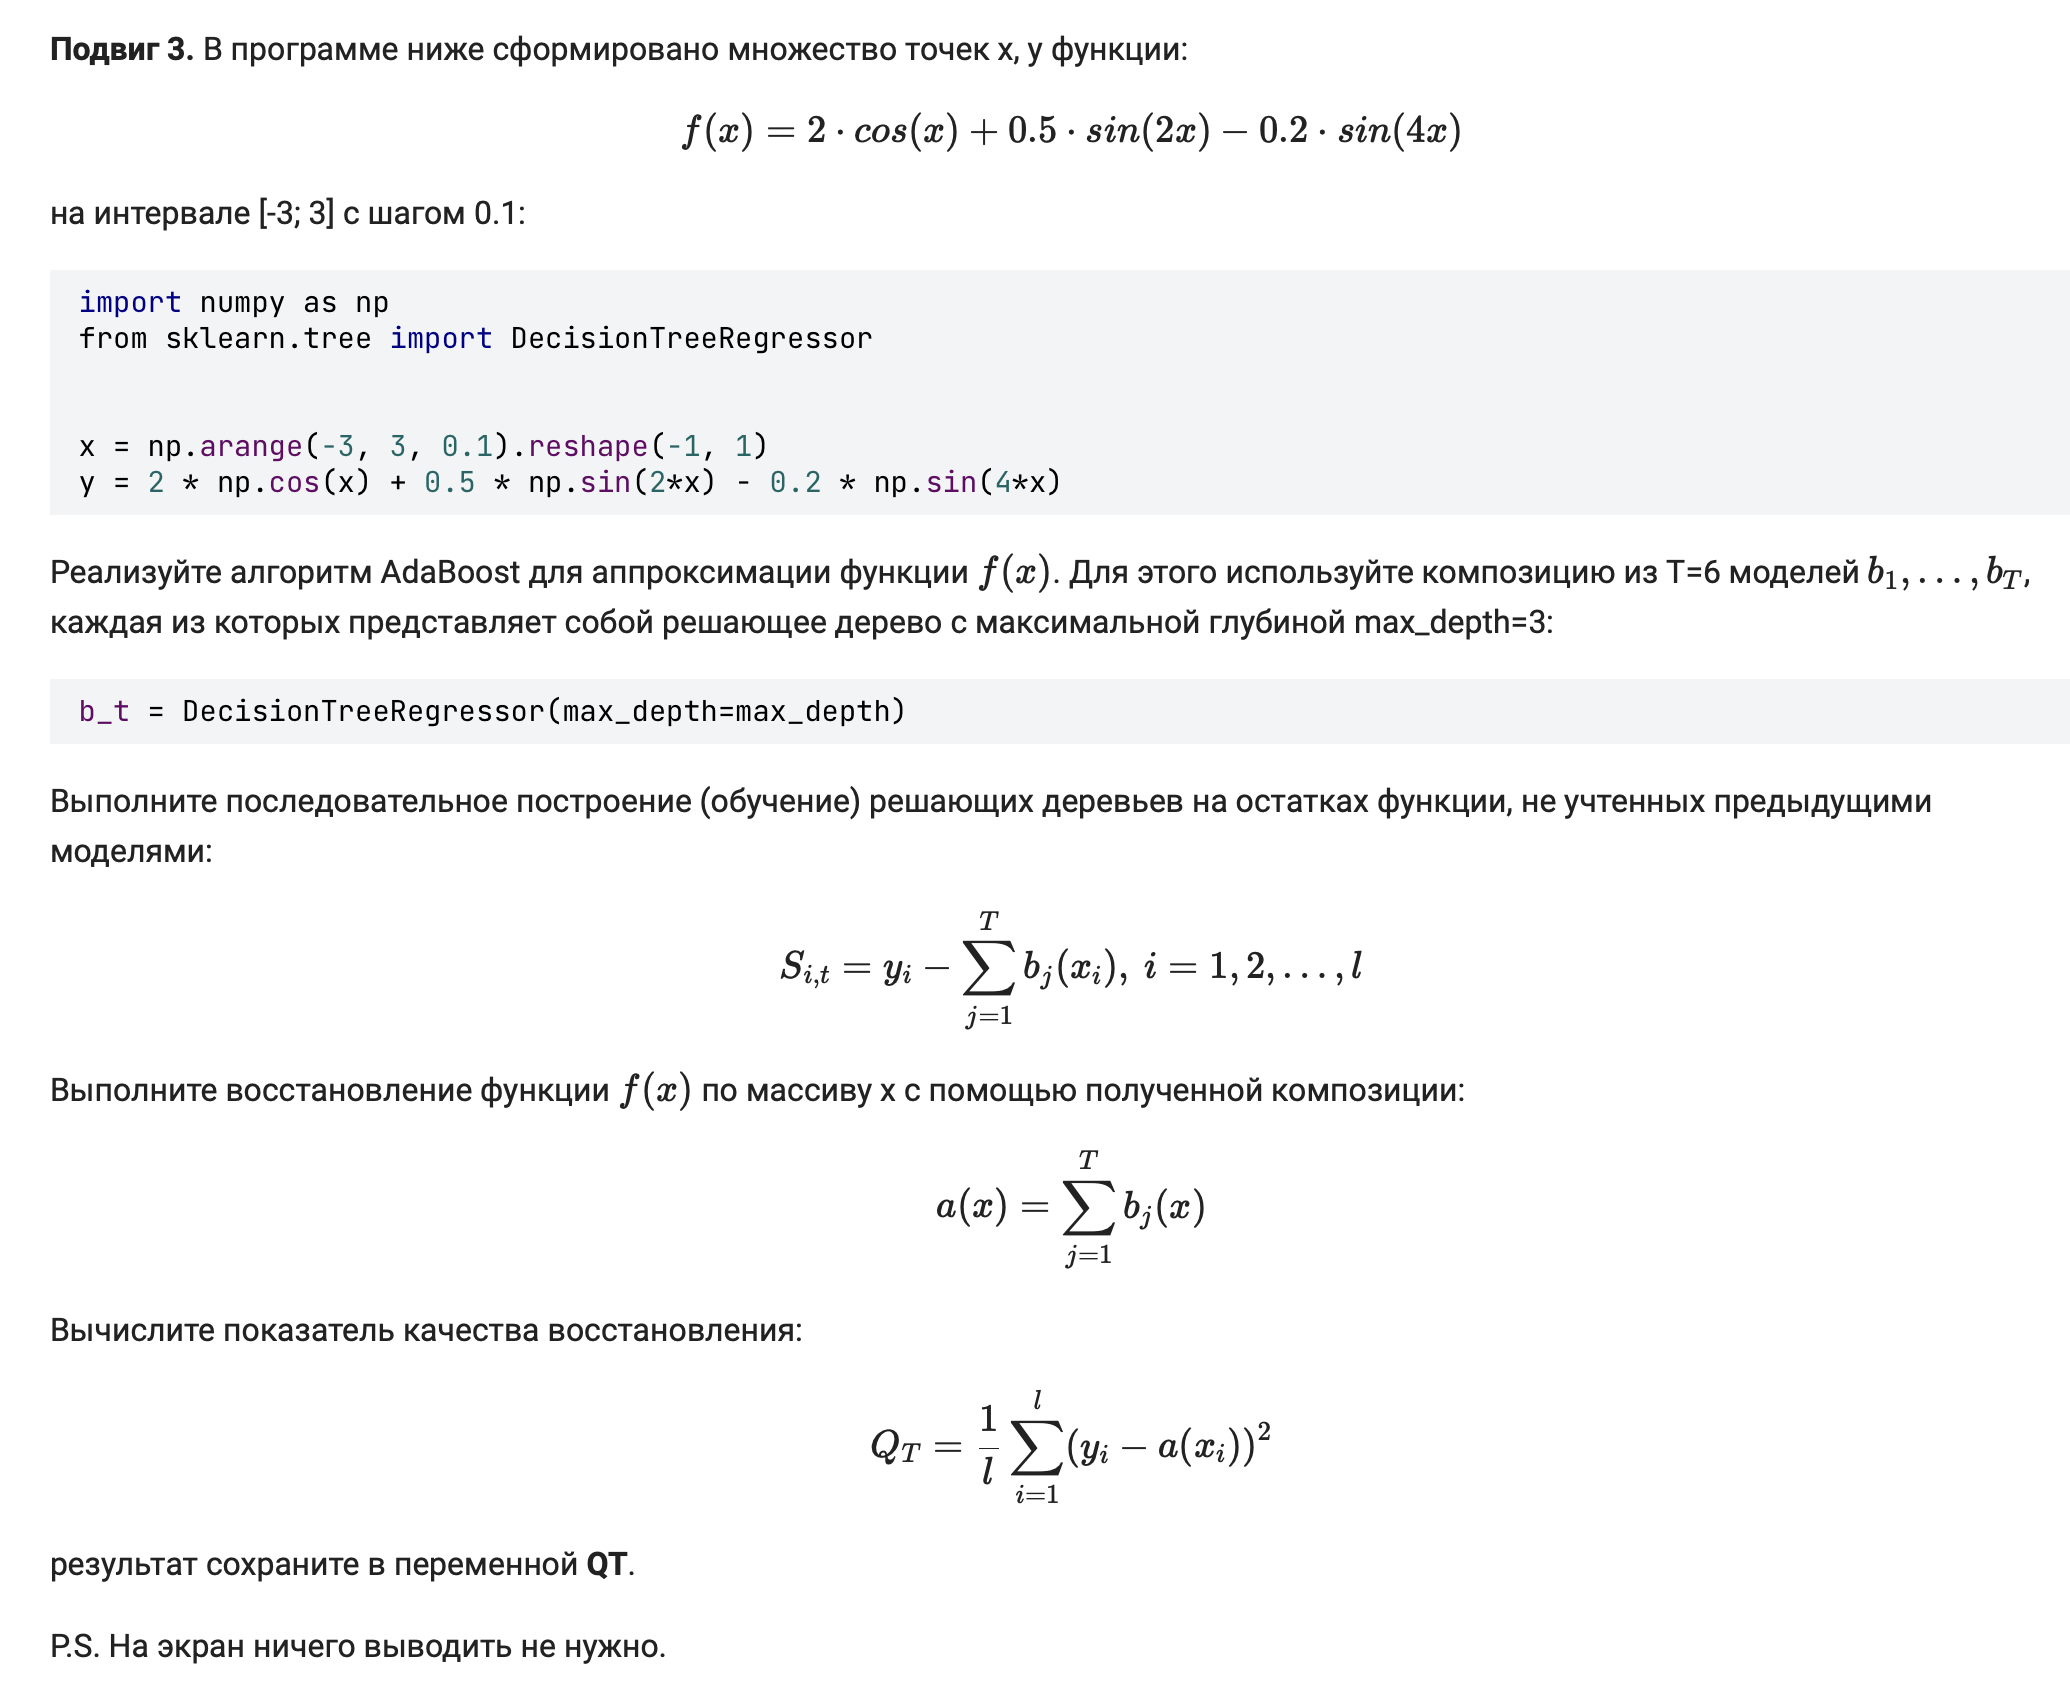

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor


x = np.arange(-3, 3, 0.1).reshape(-1, 1)
y = 2 * np.cos(x) + 0.5 * np.sin(2*x) - 0.2 * np.sin(4*x)

# здесь продолжайте программу
T = 6
s = np.array(y.ravel())
max_depth = 3

models = []
for t in range(T):
    models.append(DecisionTreeRegressor(max_depth=max_depth))
    models[-1].fit(x, s)

    s -= models[-1].predict(x)

model = lambda x, ms: np.sum([ms[i].predict(x) for i in range(len(ms))], axis=0)
pred = model(x, models)

QT = np.mean((pred - y.ravel()) ** 2)
QT

[-1.9279154  -1.9279154  -1.70832711 -1.70832711 -1.3516514  -1.3516514
 -1.02859949 -0.80815757 -0.60124677 -0.25287212 -0.25287212 -0.14706625
 -0.05275308 -0.05275308  0.01843868  0.01843868  0.01843868  0.14415352
  0.14415352  0.31262363  0.4745954   0.68970963  0.68970963  1.32826008
  1.32826008  1.32826008  1.763989    1.763989    1.97845726  1.97845726
  1.97845726  1.97845726  1.97845726  1.97845726  1.97845726  1.97845726
  1.97845726  1.97845726  1.97845726  1.97845726  1.49501107  1.49501107
  1.41584266  0.90193037  0.56617278  0.27429912 -0.10451435 -0.4779006
 -0.76239773 -1.20532904 -1.28407141 -1.69983541 -1.69983541 -1.97632755
 -1.97632755 -1.97632755 -1.97632755 -1.97632755 -1.97632755 -1.97632755] [-1.94759183 -1.87418096 -1.76464691 -1.61794929 -1.43761547 -1.23162932
 -1.01157048 -0.79112856 -0.58421776 -0.40298454 -0.25602078 -0.14706625
 -0.07441039 -0.03109577 -0.00590213  0.0150313   0.04618688  0.10055604
  0.187751    0.31262363  0.4745954   0.66779203  0.

np.float64(0.005985336650791253)